In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append(r'C:\Users\MJ\Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'D:/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.0999158391783851, 0.9779929577464789)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.5480439785042737, 0.6117157490396927)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airport_inside    0.969325
artstudio         0.929825
auditorium        0.992701
bakery            0.978462
bar               0.961456
                    ...   
tv_studio         0.992063
videostore        0.918605
waitingroom       0.975207
warehouse         1.000000
winecellar        0.990476
Length: 67, dtype: float64

In [11]:
targetF=[x  for x in each_accu.nsmallest(35).index.map(trainset.dataset.classess)]
targetF

[40,
 29,
 63,
 46,
 1,
 61,
 20,
 33,
 41,
 32,
 47,
 38,
 4,
 27,
 55,
 30,
 0,
 48,
 64,
 57,
 60,
 53,
 37,
 22,
 17,
 35,
 52,
 3,
 24,
 56,
 12,
 5,
 39,
 34,
 58]

In [12]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(6584, 5912)

In [13]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1635, 1489)

In [14]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [15]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [16]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5771257843769771,train_accu=0.6869398207426376
Epoch=0,valid_loss=0.6162244988159394,valid_accu=0.6546094750320103
0
Epoch=1,train_loss=0.4798550554259028,train_accu=0.7597631241997439
Epoch=1,valid_loss=0.584011747498213,valid_accu=0.689820742637644
0
Epoch=2,train_loss=0.37469940975060384,train_accu=0.8286651728553137
Epoch=2,valid_loss=0.6001420849111413,valid_accu=0.7135083226632523
0
Epoch=3,train_loss=0.3396316087887015,train_accu=0.8501920614596671
Epoch=3,valid_loss=0.7186832991208065,valid_accu=0.7109475032010243
Epoch=4,train_loss=0.26985869380656186,train_accu=0.8860435339308579
Epoch=4,valid_loss=0.7704376292137116,valid_accu=0.7109475032010243
Epoch=5,train_loss=0.22023006241945084,train_accu=0.9086107554417413
Epoch=5,valid_loss=0.8383707955155268,valid_accu=0.6936619718309859
Epoch=6,train_loss=0.24230540829273023,train_accu=0.90148847631242
Epoch=6,valid_loss=0.8911785474202086,valid_accu=0.6843790012804097
4 Early stopping!


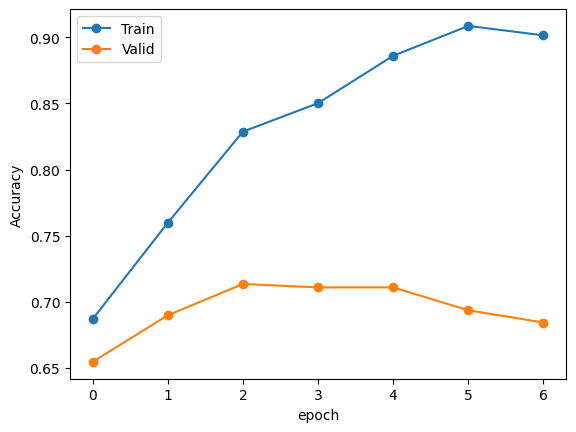

In [17]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.7795071479270842,train_accu=0.7711434370771313
Epoch=0,valid_loss=1.0996146591979437,valid_accu=0.6608462055070518
0
Epoch=1,train_loss=0.39470853800702643,train_accu=0.9002029769959404
Epoch=1,valid_loss=0.8912566976710563,valid_accu=0.7266621893888516
0
Epoch=2,train_loss=0.2191404905346637,train_accu=0.9472259810554804
Epoch=2,valid_loss=0.8928806484346025,valid_accu=0.7333781061114842
0
Epoch=3,train_loss=0.122752522916126,train_accu=0.9732746955345061
Epoch=3,valid_loss=0.9161185167074364,valid_accu=0.7494963062458025
0
Epoch=4,train_loss=0.05444137573605139,train_accu=0.9869756427604871
Epoch=4,valid_loss=0.9634898496682889,valid_accu=0.732706514439221
Epoch=5,train_loss=0.04712787247105364,train_accu=0.9883288227334236
Epoch=5,valid_loss=1.0289291024528309,valid_accu=0.7454667562122229
Epoch=6,train_loss=0.04665655392714863,train_accu=0.9901894451962111
Epoch=6,valid_loss=1.0124994052024878,valid_accu=0.7387508394895903
Epoch=7,train_loss=0.02601728599180791

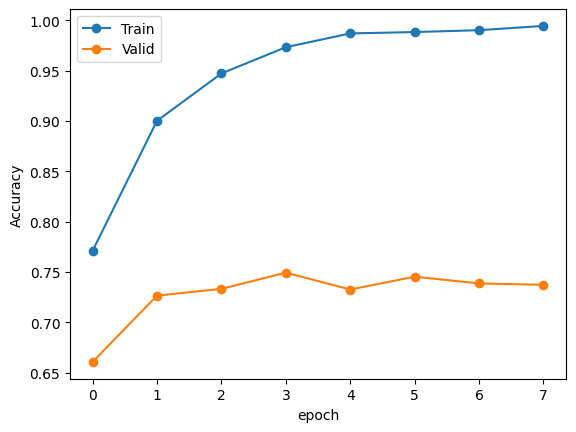

In [18]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.1554756748285213,train_accu=0.6723876063183475
Epoch=0,valid_loss=1.51579223472044,valid_accu=0.5467889908256881
0
Epoch=1,train_loss=0.6570773028009282,train_accu=0.8078675577156743
Epoch=1,valid_loss=1.2730731154800554,valid_accu=0.6250764525993884
0
Epoch=2,train_loss=0.432692157034451,train_accu=0.8765188335358445
Epoch=2,valid_loss=1.3419792236173553,valid_accu=0.5981651376146789
Epoch=3,train_loss=0.2063996071043455,train_accu=0.9419805589307412
Epoch=3,valid_loss=1.3202133545452666,valid_accu=0.6391437308868502
0
Epoch=4,train_loss=0.09805631113859892,train_accu=0.9744835965978129
Epoch=4,valid_loss=1.3216294450497408,valid_accu=0.655045871559633
0
Epoch=5,train_loss=0.05280549110865101,train_accu=0.9910388821385177
Epoch=5,valid_loss=1.3208256583695017,valid_accu=0.6568807339449542
0
Epoch=6,train_loss=0.05923595764014512,train_accu=0.9834447144592953
Epoch=6,valid_loss=1.6488744623435017,valid_accu=0.6452599388379205
Epoch=7,train_loss=0.02593506395082382,

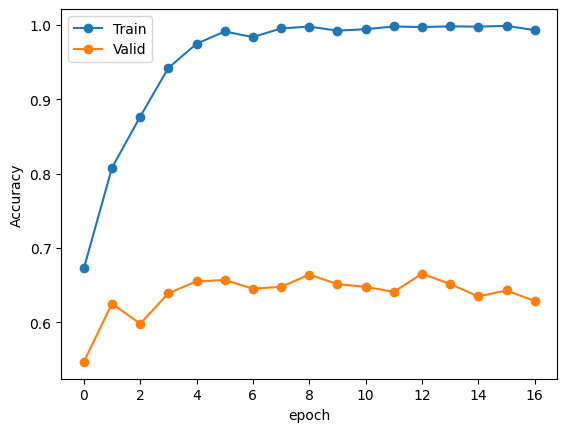

In [19]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [20]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.37469940975060384, 0.8286651728553137)

In [21]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.6001420849111413, 0.7135083226632523)

In [22]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.12275251917571273, 0.9732746955345061)

In [23]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.01400260469819083, 0.996962332928311)

In [24]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.9161182880561731, 0.7494963062458025)

In [25]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.606003772228136, 0.6654434250764526)

In [26]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.06545301256093189, 0.9857554417413572, 6584)

In [27]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.2771855345456151, 0.70550576184379, 1635)

In [28]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(3.1201810813371793, 0.8191421254801536, 7063, 5433)

In [29]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(5.88681551314194, 0.5211267605633803, 1762, 1362)

In [30]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [31]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.099916,0.977993,1.548044,0.611716
1,Model_Decision,0.374699,0.828665,0.374699,0.713508
2,Model_T,0.122753,0.973275,0.916118,0.749496
3,Model_F,0.014003,0.996962,1.606004,0.665443
4,Total_Model,3.120181,0.819142,5.886816,0.521127
5,Total_Model_without_decision,0.065453,0.985755,1.277186,0.705506


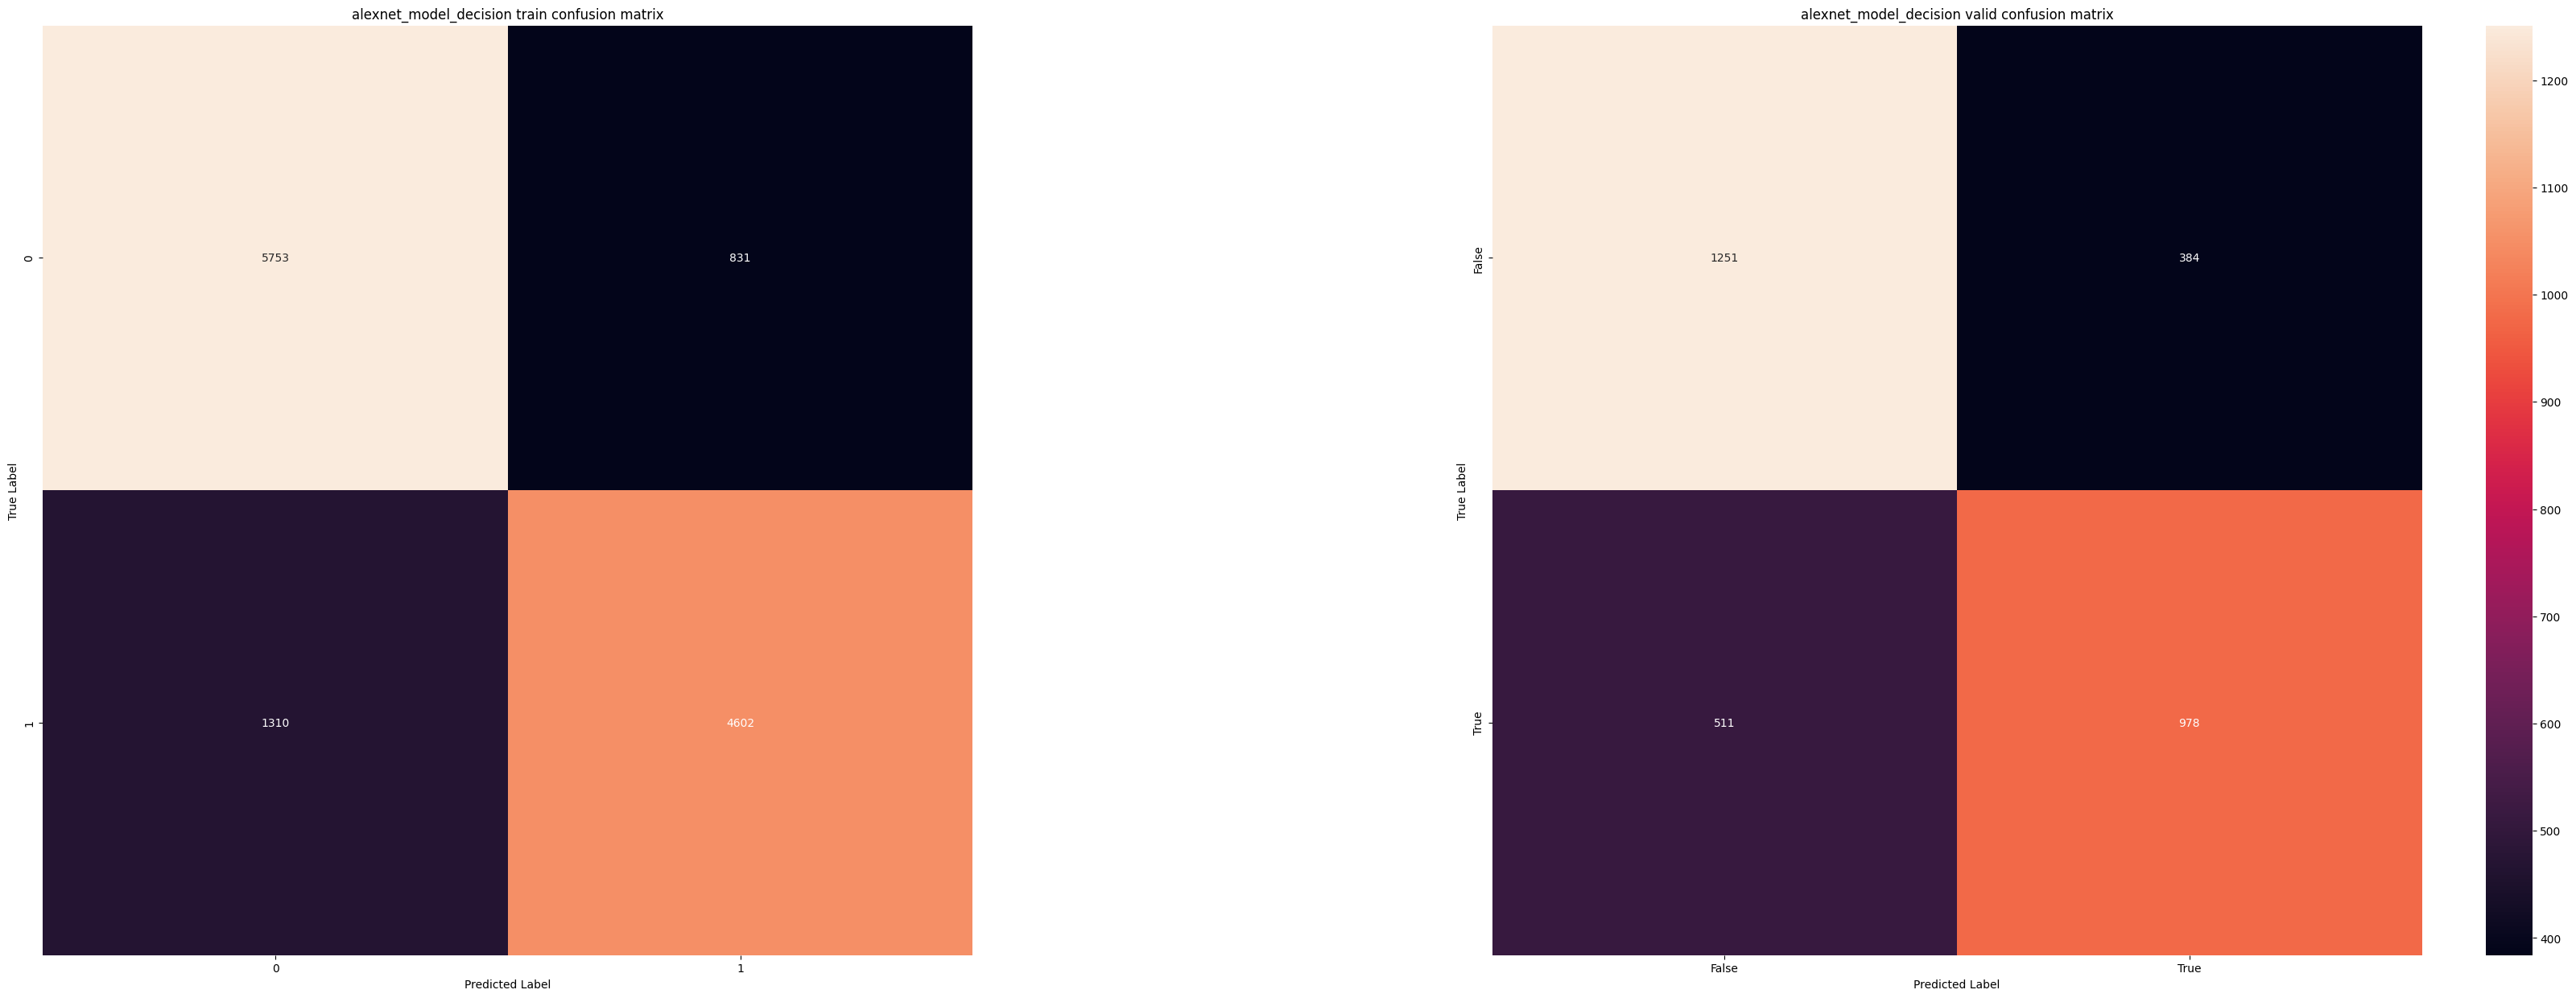

In [32]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

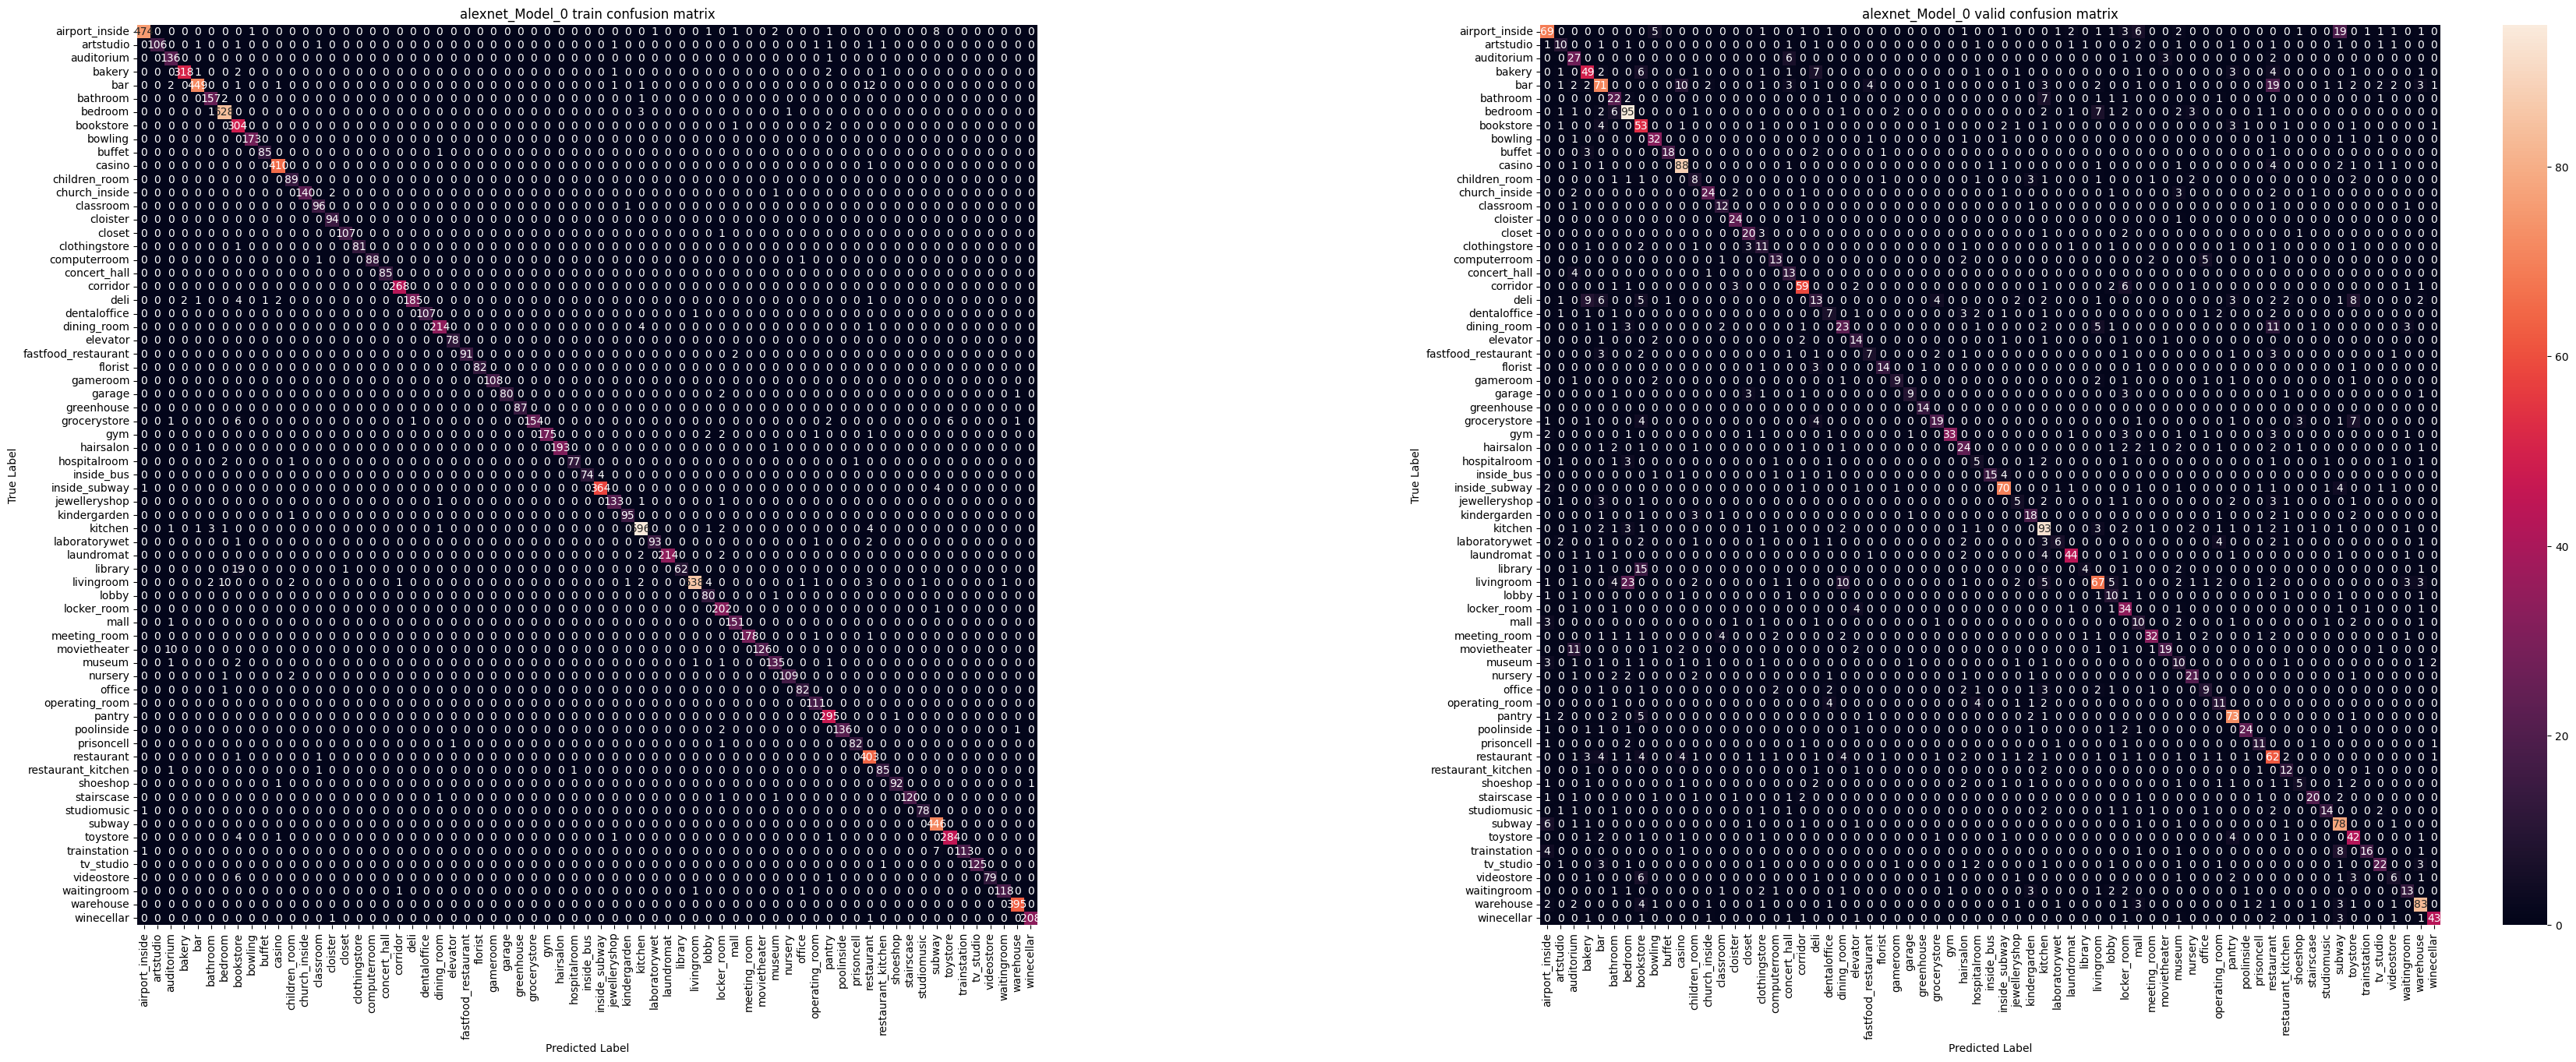

In [33]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

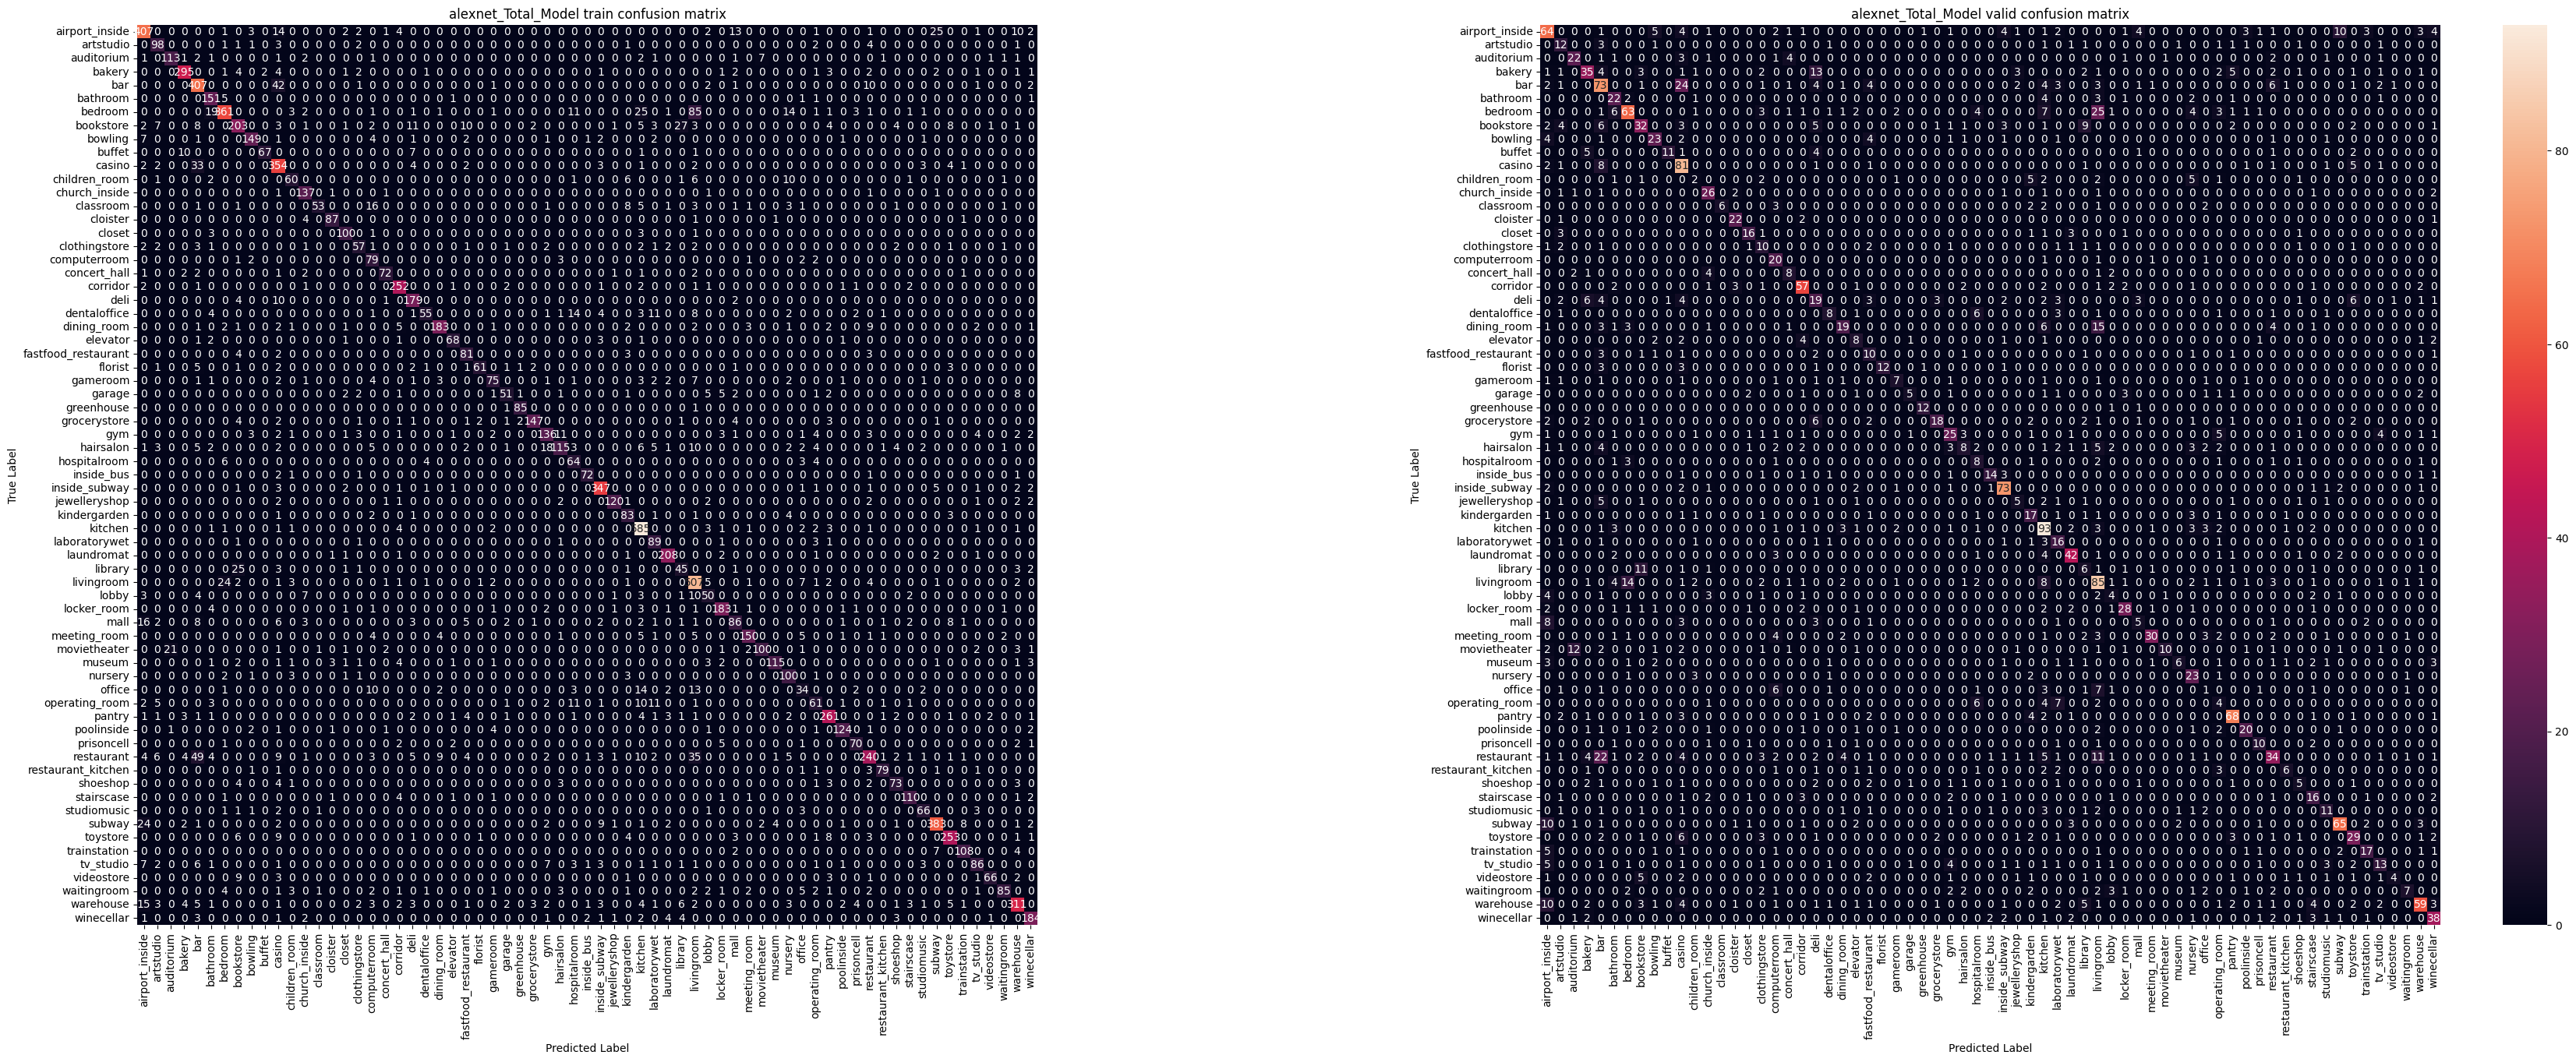

In [34]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

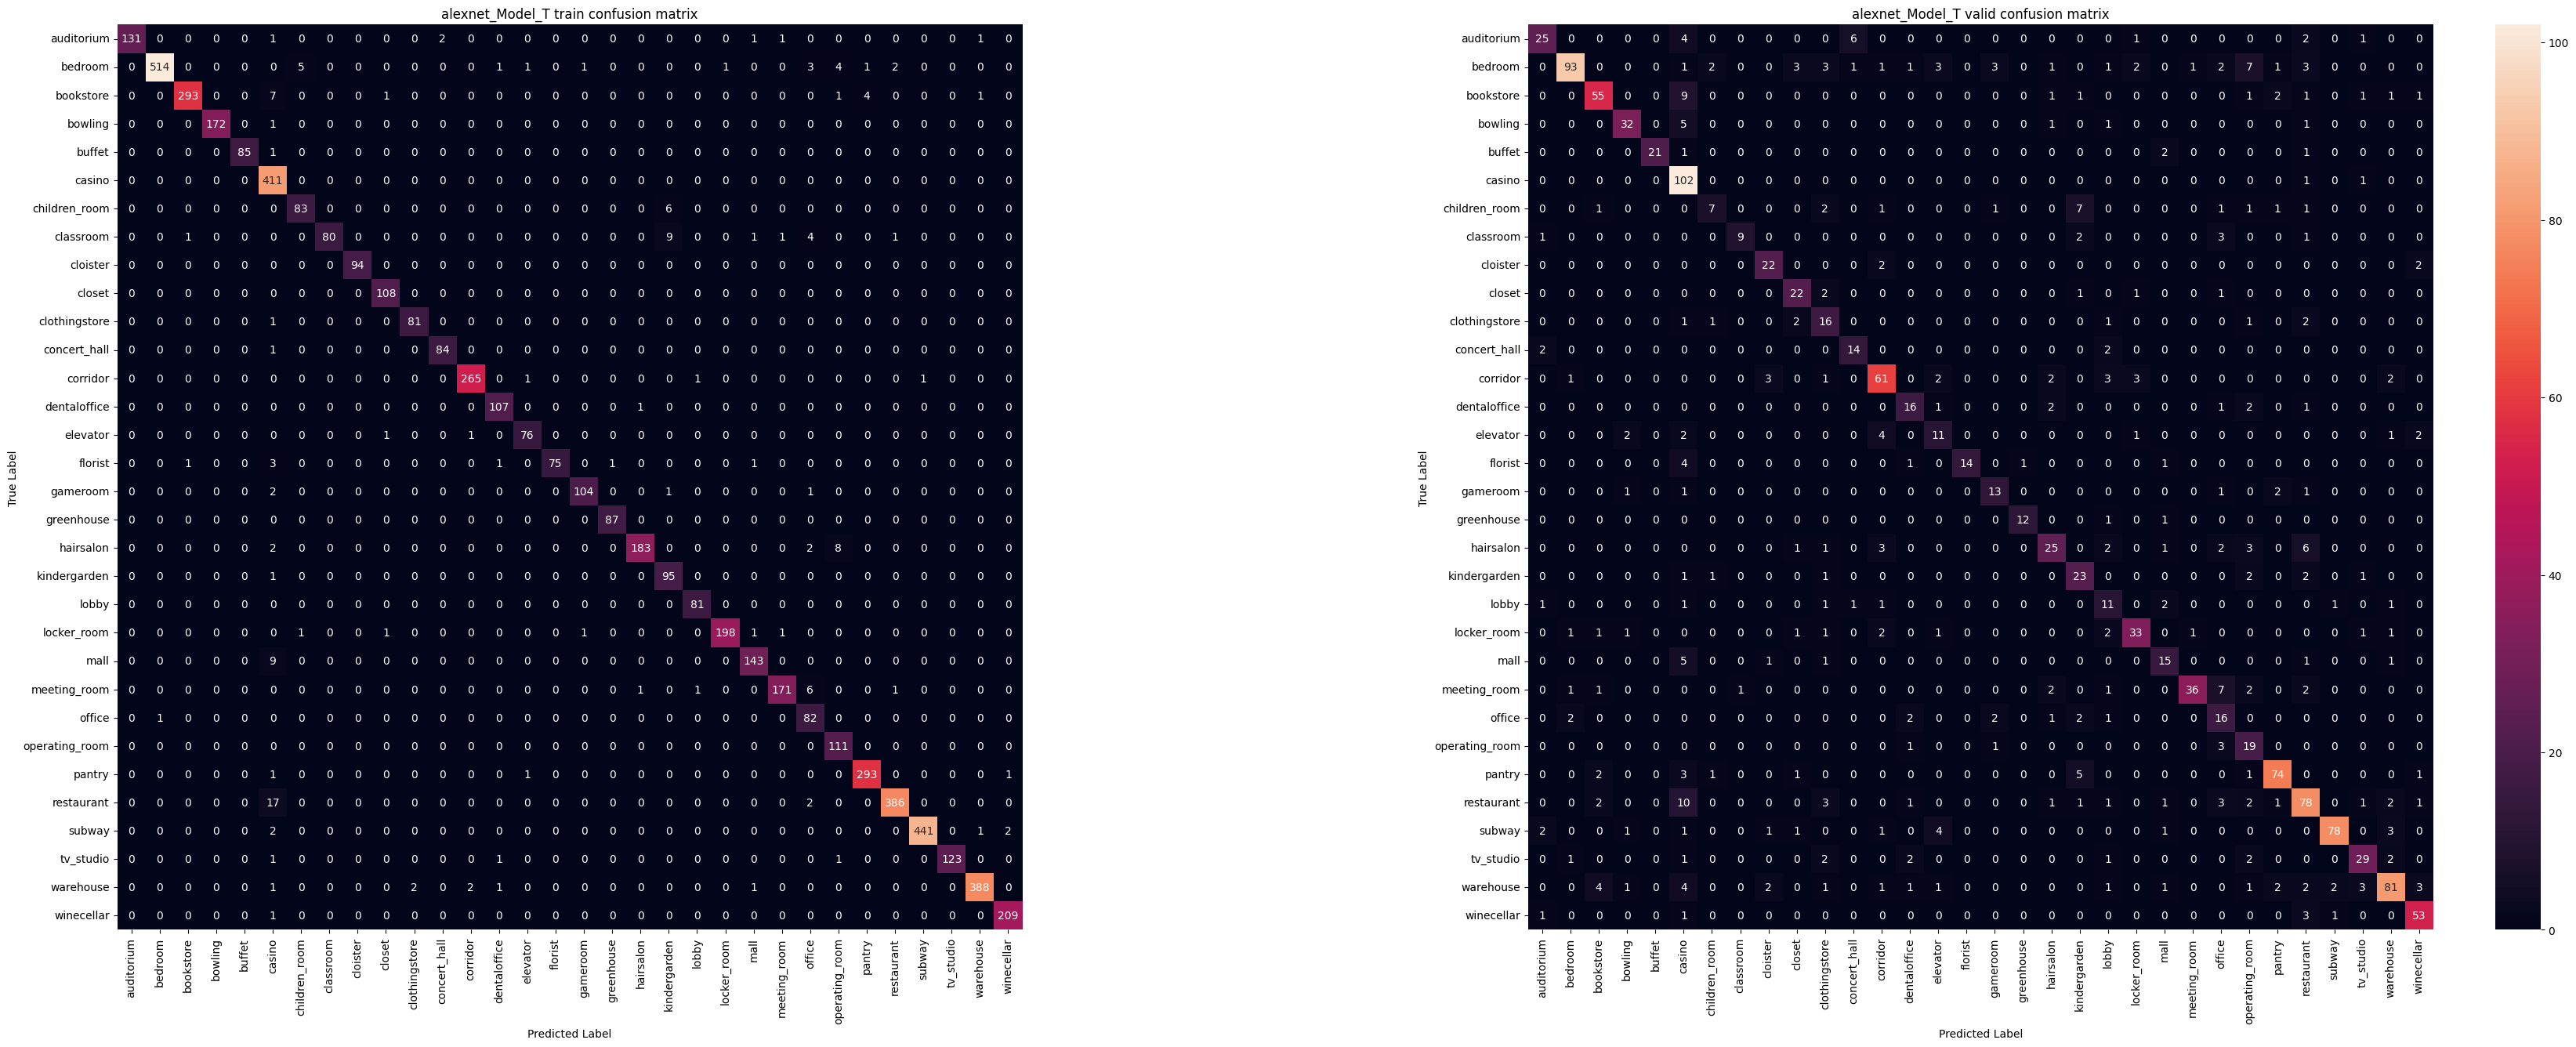

In [35]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

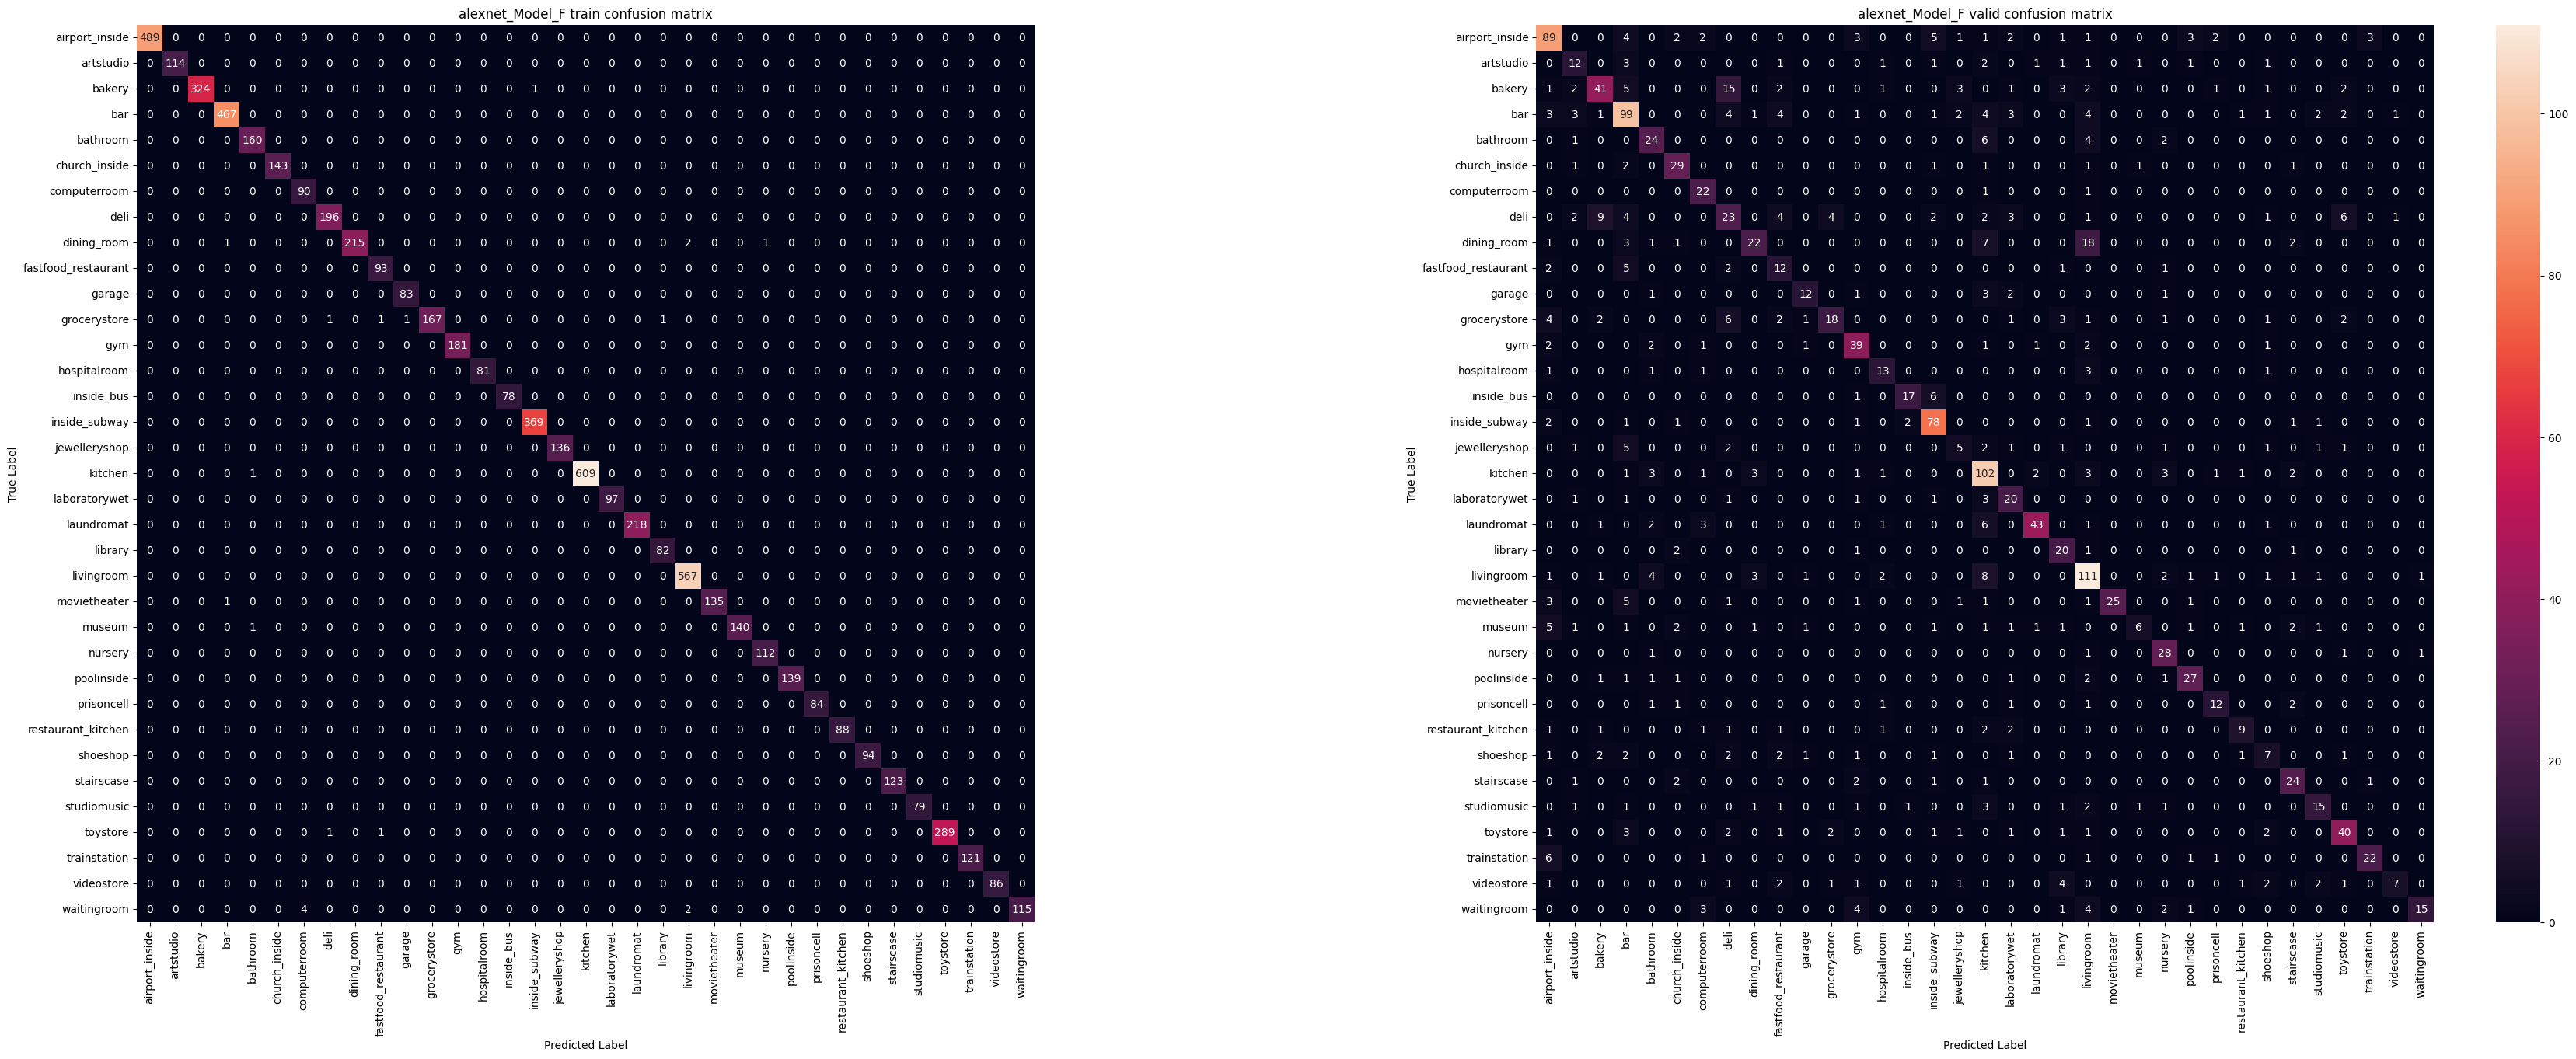

In [36]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [37]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [38]:

sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
        
            if(sf_max>st_max):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/train_size

sum_all

0.8701984635083226

In [39]:
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
        
            if(sf_max>st_max):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/valid_size
sum_all

0.7093469910371318

In [40]:
#全部模型裝在一起的表現
def total_model_softmax_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)
       
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
               
                if(sf_max_z>st_max_z):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [41]:
def calculate_zscore(softmax,avg,max_softmax,min_softmax):
    return (softmax-avg)/(max_softmax-min_softmax)

In [42]:
def calculate_lcb(data_dl,model):

    softmax_max_list = []

    # 计算每张图片的 softmax 最大值并添加到列表中
    with torch.no_grad():
        for images, labels,idx in data_dl:
            images = images.to(device)
            outputs = model(images)
            softmax_outputs = torch.softmax(outputs, dim=1)
            max_values, _ = torch.max(softmax_outputs, dim=1)
            softmax_max_list.extend(max_values.cpu().numpy())

    # 计算平均值
    avg = sum(softmax_max_list)/len(softmax_max_list)
    std = torch.tensor(softmax_max_list).std().item()

    lcb=avg-std

    max_softmax=max(softmax_max_list)
    min_softmax=min(softmax_max_list)

    return lcb,avg,std,max_softmax,min_softmax


In [43]:
##TT
lcb_T,avg_T,std_T,max_softmax_T,min_softmax_T=calculate_lcb(Tdl,model_T)
lcb_T,avg_T,std_T
##FF
lcb_F,avg_F,std_F,max_softmax_F,min_softmax_F=calculate_lcb(Fdl,model_F)
lcb_F,avg_F,std_F

(0.9522169649438029, 0.9916726022795802, 0.03945563733577728)

In [44]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_softmax_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(2.6296000945716904, 0.8614756722151088, 6086, 6410)

In [45]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_softmax_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(6.302116656578152, 0.5377720870678617, 1330, 1794)

In [46]:
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
            
            st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
            sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)

            if(sf_max_z>st_max_z):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/train_size

sum_all

0.8682778489116517

In [47]:
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
    
        for st,sf,d,idx,t in zip(softmax_T,softmax_F,data,idx,target):
         
            st_max=torch.max(st).item()
            sf_max=torch.max(sf).item()
        
            st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
            sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)

            if(sf_max_z>st_max_z):
                if(t in targetF):
                    sum_all+=1
            else:
                if(t not in targetF):
                    sum_all+=1
    sum_all=sum_all/valid_size
sum_all

0.6879001280409731

In [48]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [49]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,8687,37,37,19,37,0.996200,0.729183,0.660762,0.919641,True,False,True,False,False
1,15471,66,47,66,66,0.964924,0.999998,0.964463,0.977237,False,True,True,True,True
2,8333,37,37,6,37,0.999845,0.477070,0.842232,0.845922,True,False,True,False,False
3,15324,65,27,65,65,0.996850,0.999927,0.999768,0.728980,False,True,True,True,True
4,8358,37,37,49,37,0.998278,0.215178,0.976053,0.987670,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,11546,49,58,49,49,0.759699,0.937311,0.975900,0.924777,False,True,True,True,True
12492,9661,41,41,6,41,1.000000,0.953003,0.977076,0.561177,True,False,True,False,False
12493,12397,54,4,54,54,0.887748,0.910559,0.979042,0.732641,False,True,True,False,True
12494,6538,27,27,43,43,0.997429,0.700029,0.877271,0.815914,True,False,False,True,False


In [50]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.85)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,12330,53,53,65,23,0.999943,0.753308,0.595219,0.745030,True,False,False,True,False
16,9533,41,41,26,41,0.999986,0.303023,0.955407,0.747402,True,False,True,True,False
29,11643,50,38,50,50,0.999869,0.998349,0.991077,0.570023,False,True,True,False,True
34,338,0,0,59,0,0.999995,0.999271,0.921735,0.789947,True,False,True,True,False
45,12282,53,53,65,53,0.972235,0.464365,0.973339,0.683826,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12479,14000,60,24,10,60,0.864661,0.987409,0.990158,0.579186,False,False,True,True,False
12485,1395,4,4,54,4,0.999996,0.792395,0.932650,0.644991,True,False,True,True,False
12490,6477,27,27,51,27,0.999994,0.357193,0.883561,0.797505,True,False,True,True,False
12493,12397,54,4,54,54,0.887748,0.910559,0.979042,0.732641,False,True,True,False,True


In [51]:
df_results[df_results['Decision']!=df_results['flag']].head(30)

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
10,10293,42,37,42,42,0.984298,0.983593,0.998429,0.879095,False,True,True,False,True
11,12330,53,53,65,23,0.999943,0.753308,0.595219,0.745030,True,False,False,True,False
13,13986,60,60,51,60,0.999870,1.000000,0.939349,0.941148,True,False,True,True,False
16,9533,41,41,26,41,0.999986,0.303023,0.955407,0.747402,True,False,True,True,False
19,13706,59,0,59,59,0.995560,0.965583,0.955865,0.938855,False,True,True,False,True
24,11076,46,46,2,46,0.995298,0.558254,0.861868,0.979374,True,False,True,True,False
29,11643,50,38,50,50,0.999869,0.998349,0.991077,0.570023,False,True,True,False,True
34,338,0,0,59,0,0.999995,0.999271,0.921735,0.789947,True,False,True,True,False
45,12282,53,53,65,53,0.972235,0.464365,0.973339,0.683826,True,False,True,True,False
54,2863,7,17,7,7,0.462234,0.902332,0.831848,0.625244,False,True,True,False,True


In [52]:
df_results[df_results['Softmax_F'] >df_results['Softmax_T']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,8687,37,37,19,37,0.996200,0.729183,0.660762,0.919641,True,False,True,False,False
2,8333,37,37,6,37,0.999845,0.477070,0.842232,0.845922,True,False,True,False,False
4,8358,37,37,49,37,0.998278,0.215178,0.976053,0.987670,True,False,True,False,False
6,8131,35,35,51,35,0.998343,0.873180,0.983848,0.961789,True,False,True,False,False
7,4806,17,17,49,17,0.999962,0.590108,0.997960,0.916655,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12488,1939,5,5,21,5,0.999774,0.515297,0.907922,0.715401,True,False,True,False,False
12489,8075,35,35,54,35,0.998882,0.774981,0.987238,0.669781,True,False,True,False,False
12490,6477,27,27,51,27,0.999994,0.357193,0.883561,0.797505,True,False,True,True,False
12492,9661,41,41,6,41,1.000000,0.953003,0.977076,0.561177,True,False,True,False,False


In [53]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,10266,42,12,18,18,0.997607,0.397061,0.769922,0.856303,False,False,False,False,True
1,10879,45,17,49,64,0.971887,0.831662,0.251568,0.896783,False,False,False,True,True
2,3829,10,4,10,10,0.999995,0.999998,0.856659,0.624641,False,True,True,True,True
3,1071,3,4,54,3,0.881604,0.527475,0.671613,0.672294,False,False,True,False,False
4,2857,7,34,7,4,0.507079,0.451627,0.377278,0.629655,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3119,296,0,0,10,0,0.739630,0.322245,0.713994,0.699347,True,False,True,False,False
3120,10327,42,41,42,42,0.628310,0.914638,0.976623,0.886380,False,True,True,False,True
3121,1342,4,4,54,4,0.999586,0.861427,0.585891,0.963006,True,False,True,False,False
3122,7122,31,41,42,42,0.897624,0.952373,0.962802,0.678257,False,False,False,True,True


In [54]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(softmax_decision<0.8):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [55]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(2.103559102693742, 0.8911651728553137, 7453, 5043)

In [56]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(5.506795622780442, 0.5659411011523687, 1825, 1299)

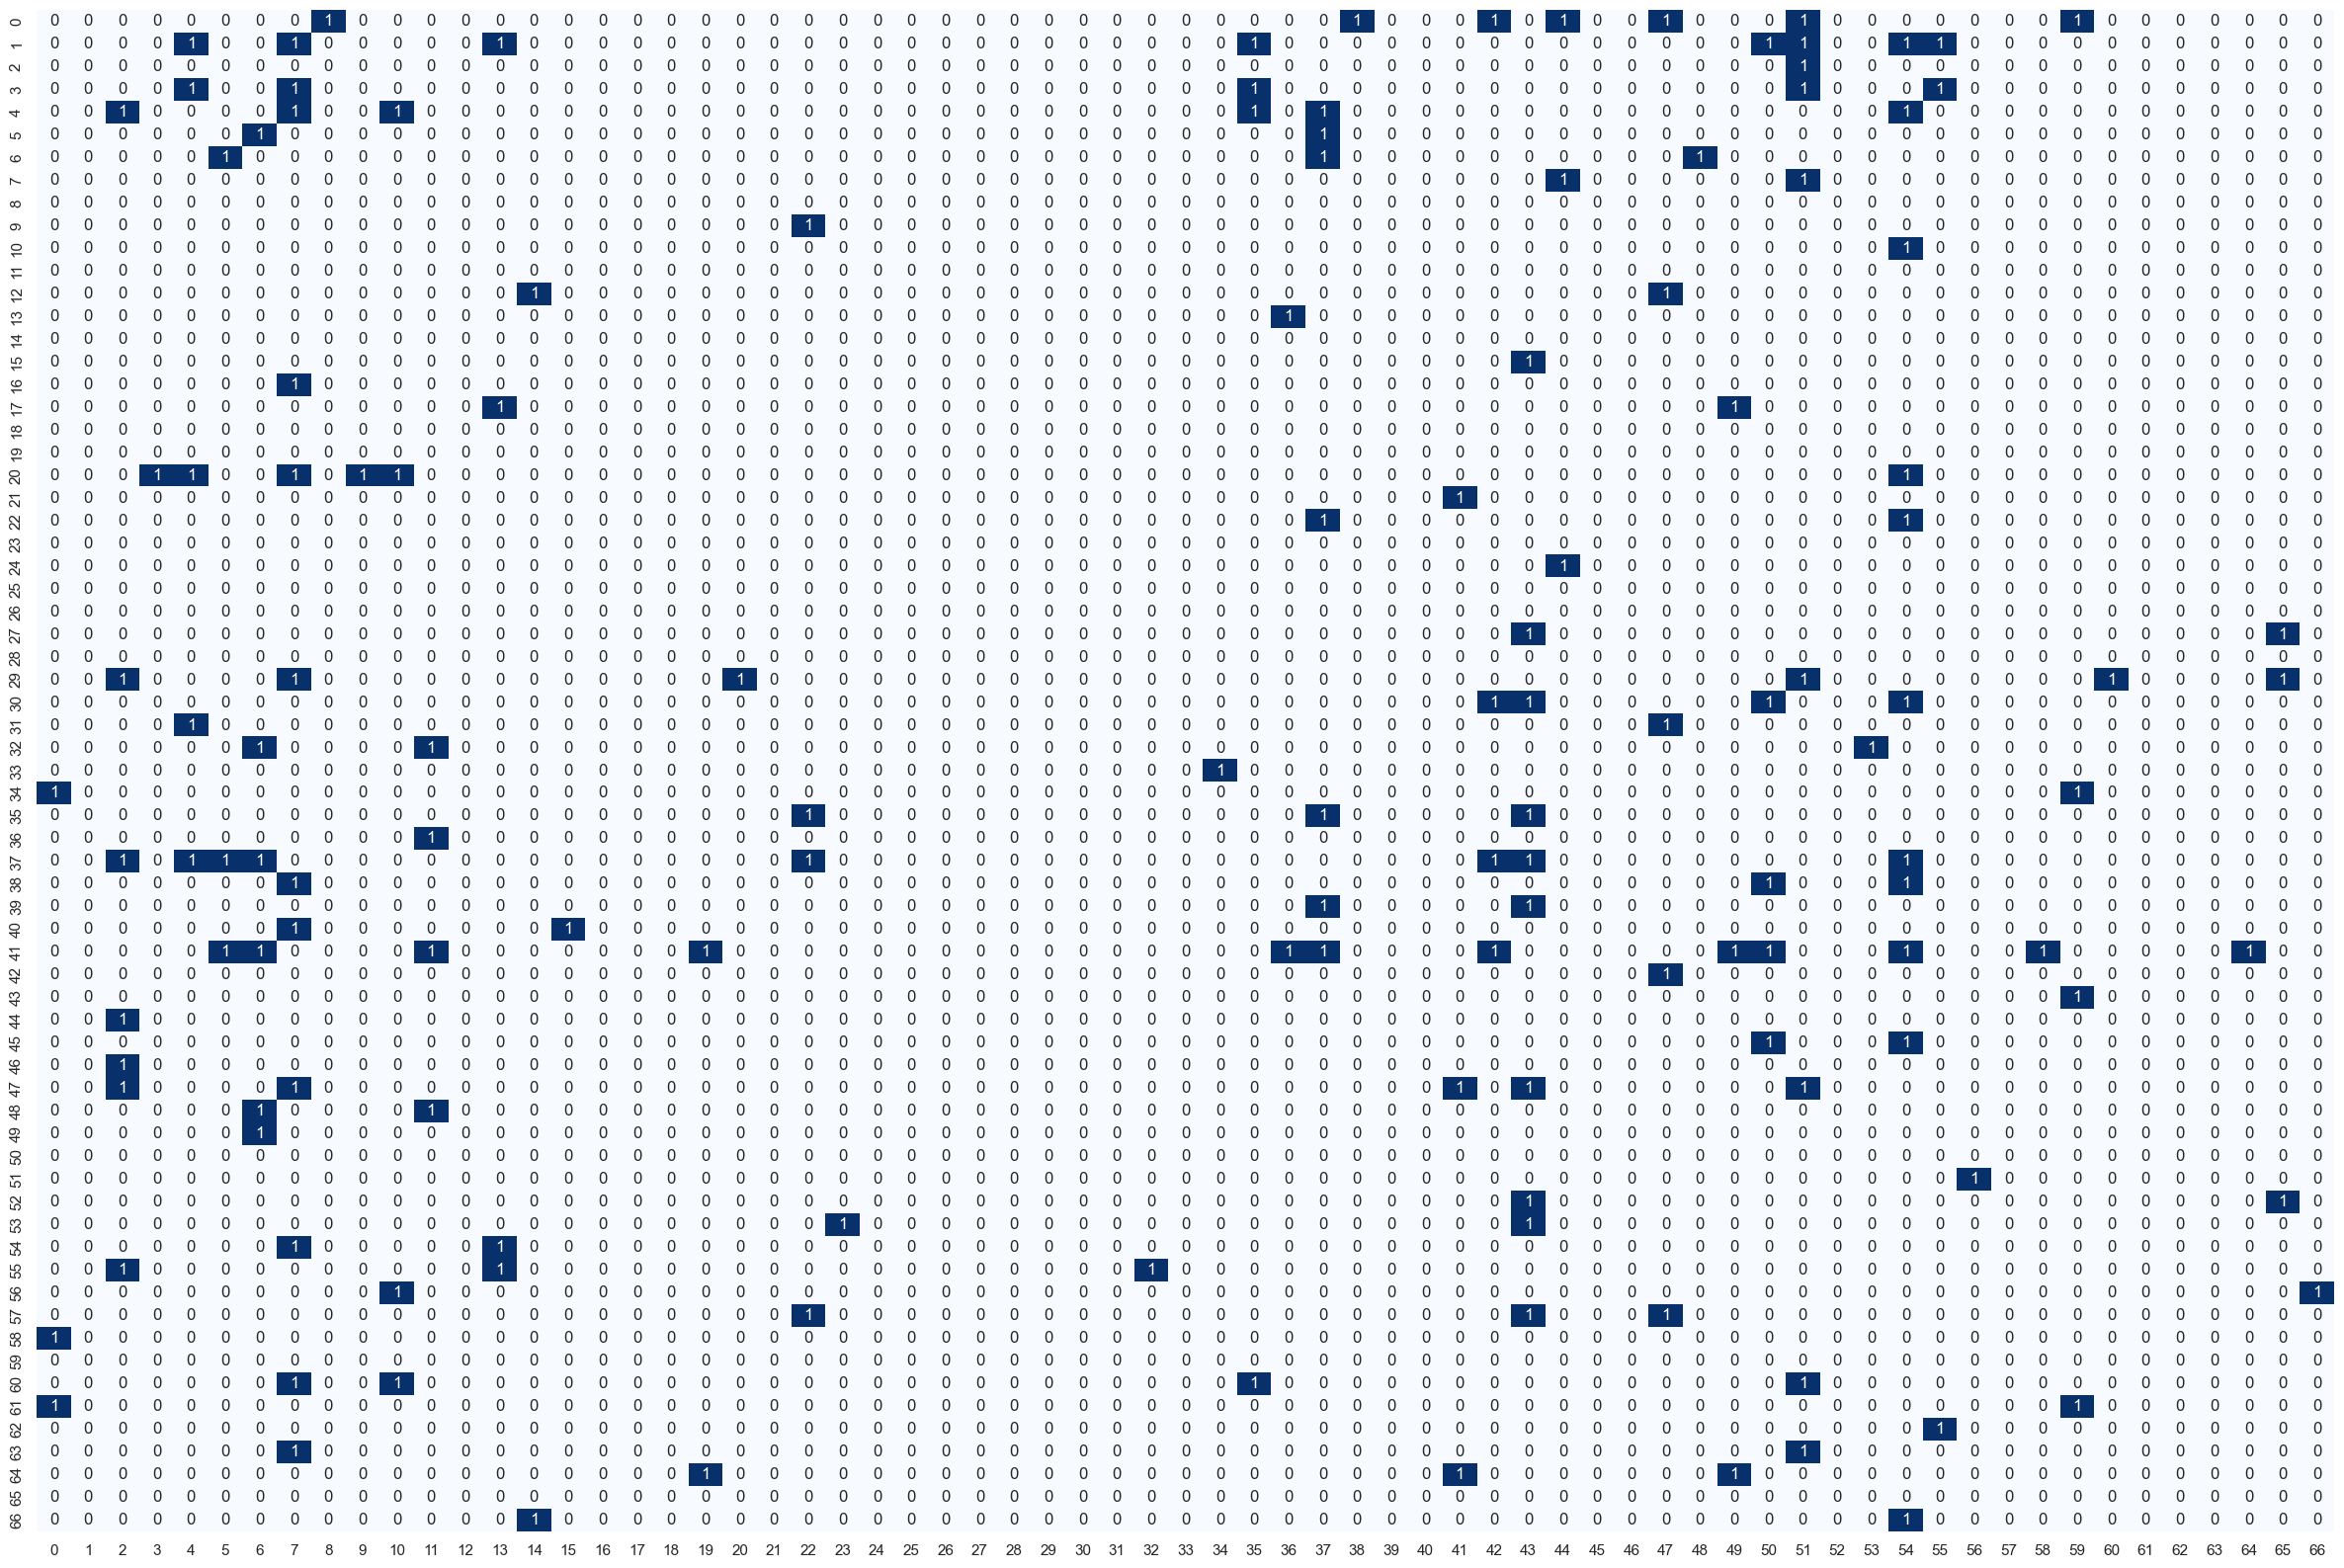

In [68]:
S = np.where(confusion_matrix_train > 0, 1, 0)

# 2. 將對角線上的元素設置為 0
np.fill_diagonal(S, 0)

# Use Seaborn to plot heatmap for confusion matrix
plt.figure(figsize=(30, 20))
sns.set(font_scale=1)  # Set font size
sns.heatmap(S, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.show()



In [58]:
# 獲取非零元素的位置
non_zero_indices = np.transpose(np.nonzero(S == 1))

# Coord 集合
Coord = [(i, j) for i, j in non_zero_indices]
print("Coord 集合:", Coord)

Coord 集合: [(0, 8), (0, 38), (0, 42), (0, 44), (0, 47), (0, 51), (0, 59), (1, 4), (1, 7), (1, 13), (1, 35), (1, 50), (1, 51), (1, 54), (1, 55), (2, 51), (3, 4), (3, 7), (3, 35), (3, 51), (3, 55), (4, 2), (4, 7), (4, 10), (4, 35), (4, 37), (4, 54), (5, 6), (5, 37), (6, 5), (6, 37), (6, 48), (7, 44), (7, 51), (9, 22), (10, 54), (12, 14), (12, 47), (13, 36), (15, 43), (16, 7), (17, 13), (17, 49), (20, 3), (20, 4), (20, 7), (20, 9), (20, 10), (20, 54), (21, 41), (22, 37), (22, 54), (24, 44), (27, 43), (27, 65), (29, 2), (29, 7), (29, 20), (29, 51), (29, 60), (29, 65), (30, 42), (30, 43), (30, 50), (30, 54), (31, 4), (31, 47), (32, 6), (32, 11), (32, 53), (33, 34), (34, 0), (34, 59), (35, 22), (35, 37), (35, 43), (36, 11), (37, 2), (37, 4), (37, 5), (37, 6), (37, 22), (37, 42), (37, 43), (37, 54), (38, 7), (38, 50), (38, 54), (39, 37), (39, 43), (40, 7), (40, 15), (41, 5), (41, 6), (41, 11), (41, 19), (41, 36), (41, 37), (41, 42), (41, 49), (41, 50), (41, 54), (41, 58), (41, 64), (42, 47), (

In [69]:
# 初始化混淆類別集合 G
G = [set(pair) for pair in Coord]
# 開始檢查是否需要合併
while True:
    merged = False
    for i in range(len(G)):
        for j in range(i+1, len(G)):
            # 檢查兩個子集的交集是否為空
            if G[i].intersection(G[j]):
                # 如果交集不是空，則合併兩個子集
                G[i] = G[i].union(G[j])
                # 將第 j 個子集標記為已合併
                G[j] = set()
                merged = True
                
    if not merged:
        break

# 刪除已標記為已合併的子集
Gp = [subset for subset in G if subset]
print("Gp:\n", Gp)

Gp:
 [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66}]


In [81]:

for i in range(len(Gp)):
    for j in range(i+1, len(Gp)):
        # 檢查兩個子集的長度是否為2
        if(len(Gp[i])==len(Gp[j])==2 and not (Gp[i].intersection(Gp[j]))):
            # 如果交集不是空，則合併兩個子集
            Gp[i] = Gp[i].union(Gp[j])
            # 將第 j 個子集標記為已合併
            Gp[j] = set()
Gv = [subset for subset in Gp if subset]
print("Gv:\n", Gv)

Gv:
 [{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66}]


In [82]:
ALL=set(range(67))
T=ALL-Gv[0]

In [85]:
T

{18, 25, 26, 28}

In [131]:
#將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):

                if(split_mode[0]=='classaccu'):
                    if(pred in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                        
                
                # elif(split_mode[0]=='wmse'):
                #     if(data_dl.dataset.dataset.loss[idx]>split_mode[1]):
                #         indexF.append(idx.cpu().numpy().item())  
                #         data_dl.dataset.dataset.update_flag(idx)
                #     else:
                #         indexT.append(idx.cpu().numpy().item())  
               

            torch.cuda.empty_cache() 
        return indexF,indexT

In [132]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',list(Gv[0]))
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(12134, 362)

In [142]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3048, 76)

In [144]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.1913231370239956,train_accu=0.93646408839779
Epoch=0,valid_loss=5.8686888845343335,valid_accu=0.5921052631578947
0
Epoch=1,train_loss=0.20013530684624753,train_accu=0.914364640883978
Epoch=1,valid_loss=6.91278086210552,valid_accu=0.5789473684210527
Epoch=2,train_loss=0.024916290763498012,train_accu=0.9917127071823204
Epoch=2,valid_loss=6.129055550223903,valid_accu=0.6447368421052632
0
Epoch=3,train_loss=0.0103813307469155,train_accu=1.0
Epoch=3,valid_loss=6.997534701698704,valid_accu=0.6447368421052632
Epoch=4,train_loss=0.002981142068245752,train_accu=1.0
Epoch=4,valid_loss=6.751996090537624,valid_accu=0.6447368421052632
Epoch=5,train_loss=0.0014362172030673995,train_accu=1.0
Epoch=5,valid_loss=7.01454872834055,valid_accu=0.6578947368421053
0
Epoch=6,train_loss=0.005596170717726837,train_accu=0.9972375690607734
Epoch=6,valid_loss=7.128147326017681,valid_accu=0.6052631578947368
Epoch=7,train_loss=0.0004064181423360142,train_accu=1.0
Epoch=7,valid_loss=7.31760361320

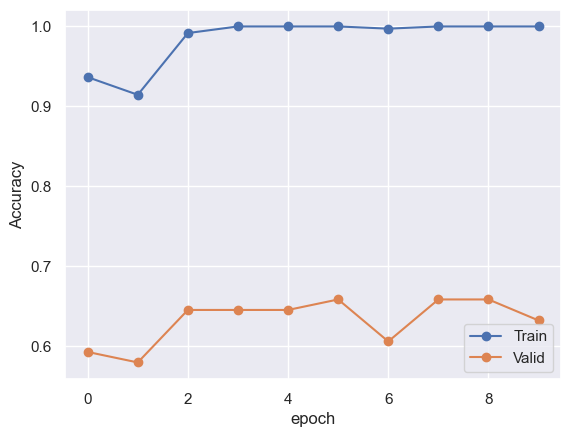

In [145]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.335424769174253,train_accu=0.631283995384869
Epoch=0,valid_loss=1.7804661623136264,valid_accu=0.5173884514435696
0
Epoch=1,train_loss=0.9125598702553334,train_accu=0.7268007252348772
Epoch=1,valid_loss=1.6836194610345394,valid_accu=0.5439632545931758
0
Epoch=2,train_loss=0.45217536370915756,train_accu=0.8915444206362287
Epoch=2,valid_loss=1.4793014207224207,valid_accu=0.6017060367454068
0
Epoch=3,train_loss=0.2503341533696807,train_accu=0.9405801879017637
Epoch=3,valid_loss=1.5235483749644962,valid_accu=0.6062992125984252
0
Epoch=4,train_loss=0.13938284403218829,train_accu=0.9656337563870117
Epoch=4,valid_loss=1.62376515821522,valid_accu=0.6085958005249343
0
Epoch=5,train_loss=0.08632069394312945,train_accu=0.9803032800395582
Epoch=5,valid_loss=1.7174143540890512,valid_accu=0.6003937007874016
Epoch=6,train_loss=0.05267709858521502,train_accu=0.989039063787704
Epoch=6,valid_loss=1.7998420603944874,valid_accu=0.6115485564304461
0
Epoch=7,train_loss=0.0309595238842772

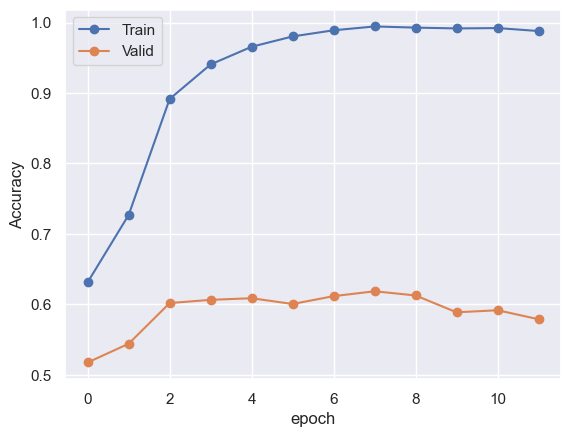

In [146]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [147]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0014362179035692635, 1.0)

In [148]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.030959533711393997, 0.9944783253667381)

In [149]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(7.0145587168241805, 0.6578947368421053)

In [150]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.8502710672814076, 0.6184383202099738)

In [158]:
#全部模型裝在一起的表現
def total_model_confusion_evaluate(data_dl,size,model_0,model_T,model_F,targetF):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)
            _, y_pred = torch.max(out_growth, dim = 1) 
            
            for pred,d in zip(y_pred,data):
             
                if(pred.item() not in targetF):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                    # softmax_T=torch.softmax(out_T, dim=1)
                else:
                    
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
                    # softmax_F=torch.softmax(out_F, dim=1)

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [159]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_confusion_evaluate(train_dl,train_size,model_0,model_T,model_F,targetF=list(Gv[0]))
total_loss,accu,sum_F,sum_T

(0.03010440333961019, 0.9947183098591549, 12134, 362)

In [160]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_confusion_evaluate(valid_dl,valid_size,model_0,model_T,model_F,targetF=list(Gv[0]))
total_loss,accu,sum_F,sum_T

(1.9759025949216835, 0.6197183098591549, 3048, 76)